In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

print("at directory:", os.getcwd())
print("changing to root directory")
os.chdir("..")
print("at directory:", os.getcwd())
sys.path.append("simulations")

at directory: /Users/wilka/git/research/multitask_preplay/figures
changing to root directory
at directory: /Users/wilka/git/research/multitask_preplay


In [3]:
%matplotlib inline

# Load data

In [4]:
from data_processing import process_model_data

# %debug
model_df = process_model_data.get_craftax_model_data()

Loading textures from cache.
Textures successfully loaded from cache.
Loading textures from cache.
Textures successfully loaded from cache.
Generating model data for qlearning
Generating model data for usfa
Generating model data for dyna
Generating model data for preplay


In [9]:
model_df.filter(algo="preplay").head()

domain,algo,user_id,manipulation,world,block_name,condition,task_set,global_episode_idx,corresponding_train_episode_idx,success,overlap,eval,start_pos,total_reward,path_length,task_vector,task_object_id,reuse,train_test_cosine
str,str,i64,str,str,str,i64,i64,i64,i32,f64,f64,bool,str,f64,i64,str,i64,i32,f64
"""craftax""","""preplay""",1,"""paths""","""3""","""3""",0,0,0,-1,1.0,NaN,false,"""[28 25]""",1.0,46,"""[0. 1. 0.]""",21,-1,NaN
"""craftax""","""preplay""",1,"""paths""","""15""","""15""",0,0,1,-1,1.0,NaN,false,"""[24 24]""",1.0,54,"""[0. 0. 1.]""",22,-1,NaN
"""craftax""","""preplay""",1,"""paths""","""20""","""20""",0,0,2,-1,1.0,NaN,false,"""[18 30]""",1.0,46,"""[1. 0. 0.]""",10,-1,NaN
"""craftax""","""preplay""",1,"""paths""","""95""","""95""",0,0,3,-1,1.0,NaN,false,"""[ 7 16]""",1.0,35,"""[0. 1. 0.]""",21,-1,NaN
"""craftax""","""preplay""",1,"""paths""","""3""","""3""",0,0,4,0,1.0,0.837838,true,"""[28 25]""",1.0,52,"""[1. 0. 0.]""",10,1,0.983826


In [6]:
from data_processing import process_user_data

user_df = process_user_data.get_craftax_human_data()

Compiling environment reset and step functions.
	reset time: 10.956155776977539
	step time: 13.76127576828003
Compiling multi-render function.
	time: 2.928267002105713
GENERATING ../preplay_results/data/craftax/final/human_data_episode_df.parquet
LOADING ../preplay_results/data/craftax/final/human_data_episode_df.parquet


# Analysis

A* (39, 46) Iterations: 0it [00:00, ?it/s]

A* (38, 46) Iterations: 0it [00:00, ?it/s]

A* (40, 32) Iterations: 0it [00:00, ?it/s]

A* (6, 34) Iterations: 0it [00:00, ?it/s]

Loading cached user IDs from /Users/wilka/git/research/multitask_preplay/analysis/paper_results_cache/path_reuse_manipulation_analysis_tell_reuse_user_ids.pkl
Num users after cache filter:  200
Removed 3 global episode indices
Removed 8 global episode indices
Removed 0 global episode indices


/Users/wilka/git/research/multitask_preplay/analysis/analysis_utils.py:1281: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  _, normality_p = stats.shapiro(rates)
/Users/wilka/miniforge3/envs/preplay/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/Users/wilka/miniforge3/envs/preplay/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Sample size too small for normal approximation.
  res = hypotest_fun_out(*samples, **kwds)


Removed 2 global episode indices
Removed 1 global episode indices
Removed 8 global episode indices
Removed 0 global episode indices
Removed 0 global episode indices


/Users/wilka/git/research/multitask_preplay/analysis/analysis_utils.py:1281: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  _, normality_p = stats.shapiro(rates)
/Users/wilka/miniforge3/envs/preplay/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/Users/wilka/miniforge3/envs/preplay/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Sample size too small for normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/Users/wilka/git/research/multitask_preplay/analysis/craftax_analysis.py:566: UserWarning: You passed a edgecolor/edgecolors ('#186CED') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


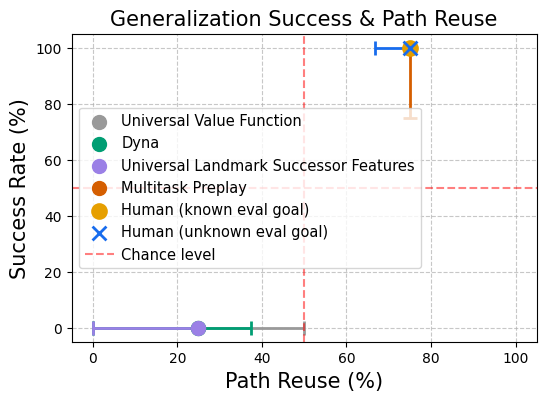

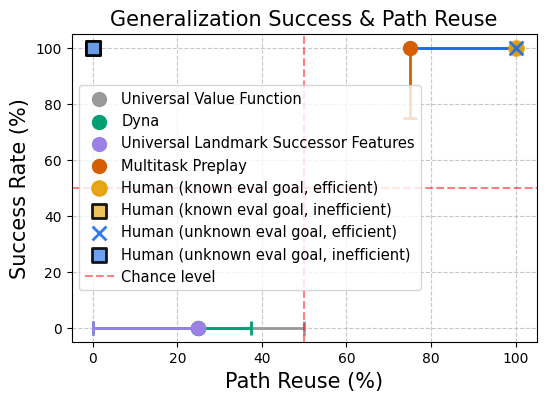

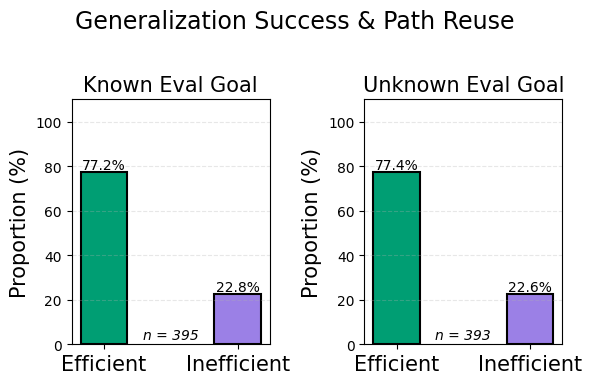

In [7]:
from analysis import craftax_analysis
import data_configs

# %debug
craftax_analysis.path_reuse_manipulation_analysis(
  user_df=user_df,
  model_df=model_df,
  overlap_threshold=0.25,
  cosine_threshold=.5,
  legend_loc="center left",
)

# Which maps was reuse = 0

Loading cached user IDs from /Users/wilka/git/research/preplay_results/cache/plot_non_reuse_frequency_by_world_seed_tell_reuse_user_ids.pkl
Num users after cache filter:  200
Saved plot to /tmp/reuse_analysis/non_reuse_frequency_by_seed.pdf


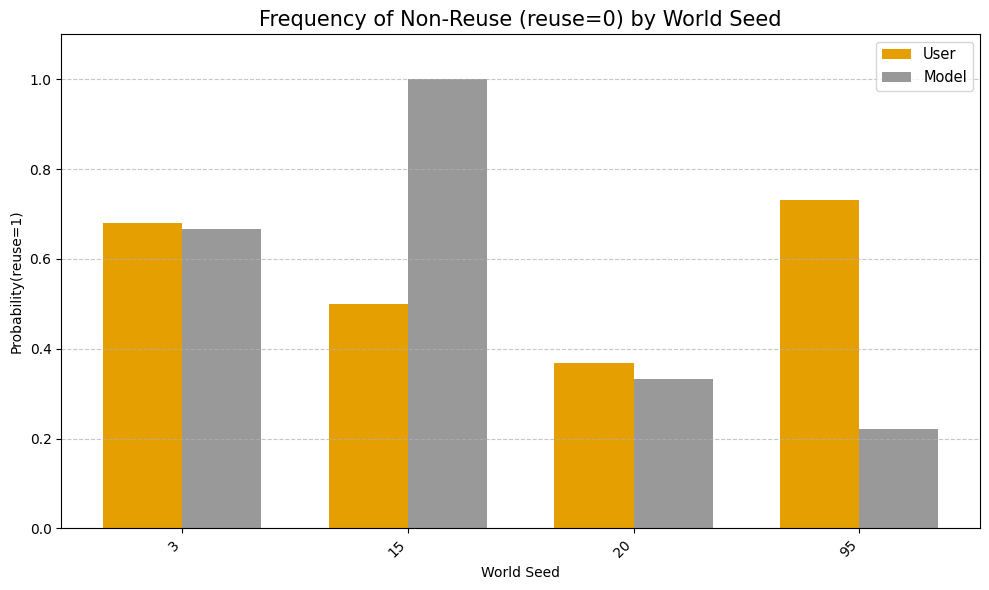

In [23]:
fig, ax = craftax_analysis.plot_non_reuse_frequency_by_world_seed(
  user_df=user_df,
  model_df=model_df,
  # reuse_column="efficient_reuse_2",
  tell_reuse=0,
  save_dir="/tmp/reuse_analysis",
)
# fig, ax = craftax_analysis.plot_non_reuse_frequency_by_world_seed(
#   user_df=user_df,
#   model_df=model_df,
#   # reuse_column="efficient_reuse_2",
#   tell_reuse=1,
#   save_dir="/tmp/reuse_analysis",
# )
# plt.show()

# Individual analysis

In [36]:
filter = dict(tell_reuse=0)
sub_df = user_df.filter(**filter)
users = sub_df["user_id"].unique()
users

In [37]:
users = sub_df["user_id"].unique()
users

user_id
i64
10434196
122928105
818906834
2349435691
2540827707
…
3638567733
3651975810
3817231829







10434196


,index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,suboptimal_path,efficient_1.25,efficient_1.5,efficient_1.75,efficient_2,path_length_deviance,success,path_length,termination,first_log_rt,avg_log_rt,total_log_rt,log_avg_post_rt,max_log_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,reuse,overlap,efficient_reuse_1.25,efficient_reuse_1.5,efficient_reuse_1.75,efficient_reuse_2
0,0,3,1,paths_0_eval1,reusing longer of two paths which matches training path,paths,16,1,True,10,0,[28 25],10434196,33,Female,craftax_v3-paths-r0-m0,0,0,0,3,34,False,True,True,True,True,4,1.0,38,1.0,6.904751,5.827946,221.46196,5.798843,7.734121,7.734121,6.487684,6.694562,7.734121,1,0.295082,True,True,True,True


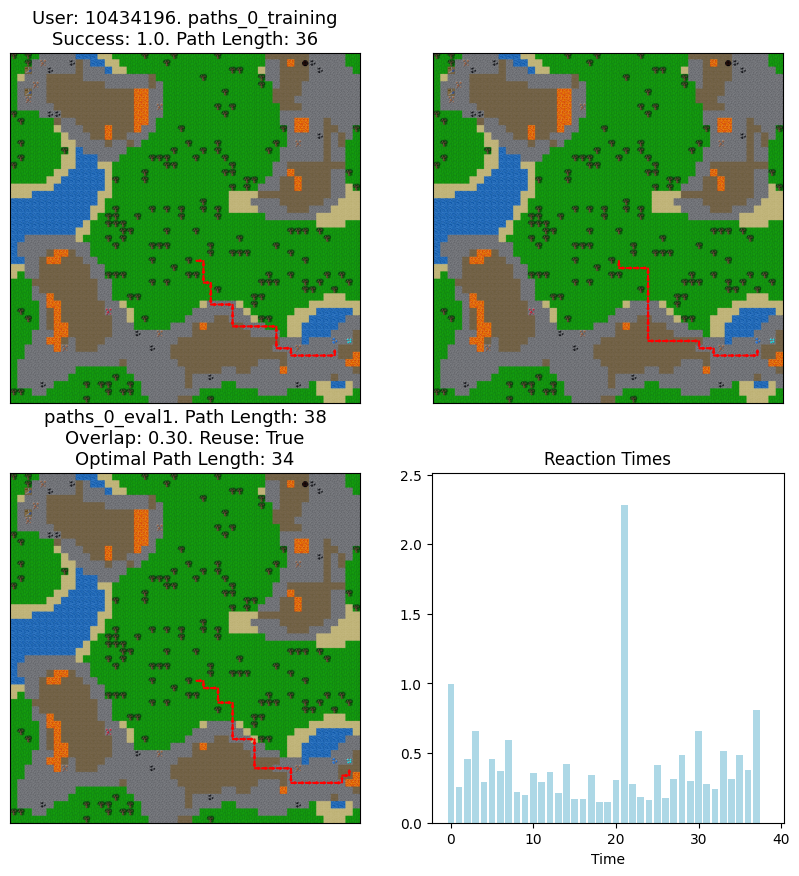

,index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,suboptimal_path,efficient_1.25,efficient_1.5,efficient_1.75,efficient_2,path_length_deviance,success,path_length,termination,first_log_rt,avg_log_rt,total_log_rt,log_avg_post_rt,max_log_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,reuse,overlap,efficient_reuse_1.25,efficient_reuse_1.5,efficient_reuse_1.75,efficient_reuse_2
0,0,15,1,paths_1_eval1,reusing longer of two paths which matches training path,paths,33,1,True,21,0,[24 24],10434196,33,Female,craftax_v3-paths-r0-m0,0,0,0,3,38,False,True,True,True,True,7,1.0,45,1.0,7.999343,5.611753,252.52887,5.557489,7.999343,7.639161,6.768493,7.639161,7.639161,1,0.30137,True,True,True,True


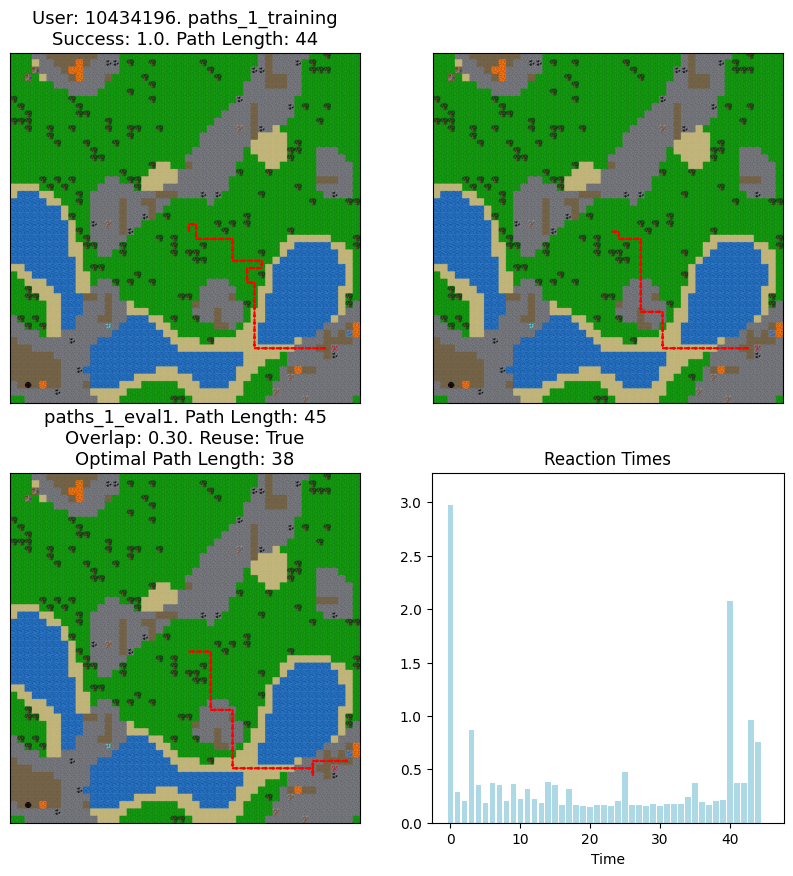

No test episodes for maze: paths_2_eval1


,index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,suboptimal_path,efficient_1.25,efficient_1.5,efficient_1.75,efficient_2,path_length_deviance,success,path_length,termination,first_log_rt,avg_log_rt,total_log_rt,log_avg_post_rt,max_log_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,reuse,overlap,efficient_reuse_1.25,efficient_reuse_1.5,efficient_reuse_1.75,efficient_reuse_2
0,0,95,1,paths_3_eval1,reusing longer of two paths which matches training path,paths,50,1,True,10,0,[ 7 16],10434196,33,Female,craftax_v3-paths-r0-m0,0,0,0,3,27,False,True,True,True,True,4,1.0,31,1.0,6.625392,5.490521,170.206146,5.452692,6.650279,6.650279,6.530878,6.650279,6.650279,1,0.169492,True,True,True,True


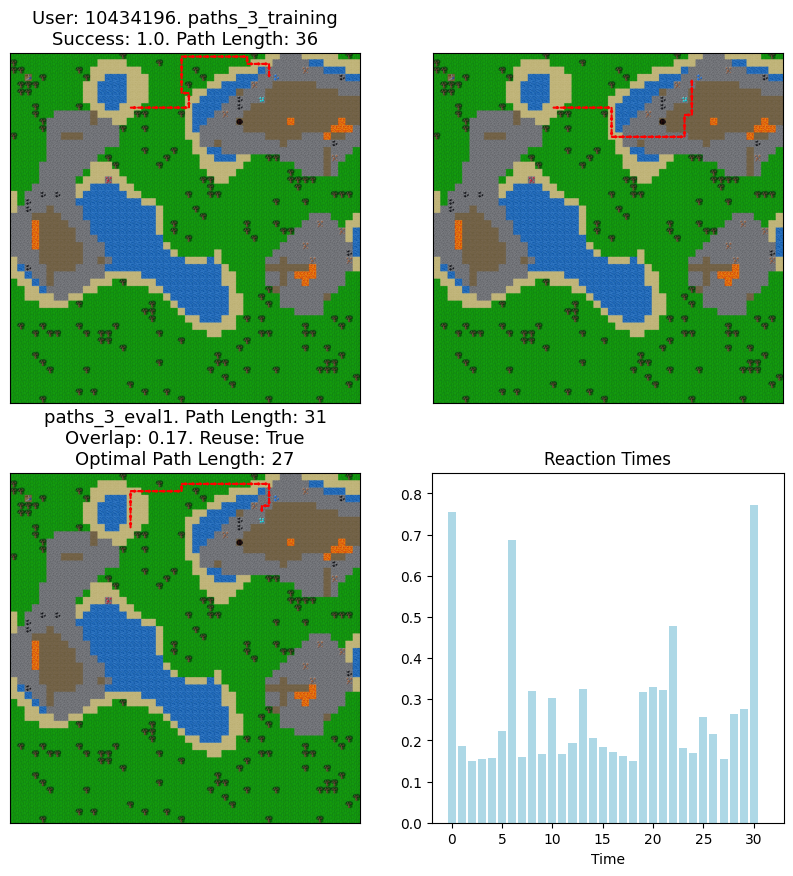






122928105


,index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,suboptimal_path,efficient_1.25,efficient_1.5,efficient_1.75,efficient_2,path_length_deviance,success,path_length,termination,first_log_rt,avg_log_rt,total_log_rt,log_avg_post_rt,max_log_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,reuse,overlap,efficient_reuse_1.25,efficient_reuse_1.5,efficient_reuse_1.75,efficient_reuse_2
0,0,3,1,paths_0_eval1,reusing longer of two paths which matches training path,paths,33,1,True,10,0,[28 25],122928105,53,Female,craftax_v3-paths-r0-m0,0,0,0,3,34,False,True,True,True,True,4,1.0,38,1.0,8.606851,6.000597,228.022705,5.930158,8.606851,7.336937,6.463029,7.336937,7.336937,1,0.297297,True,True,True,True


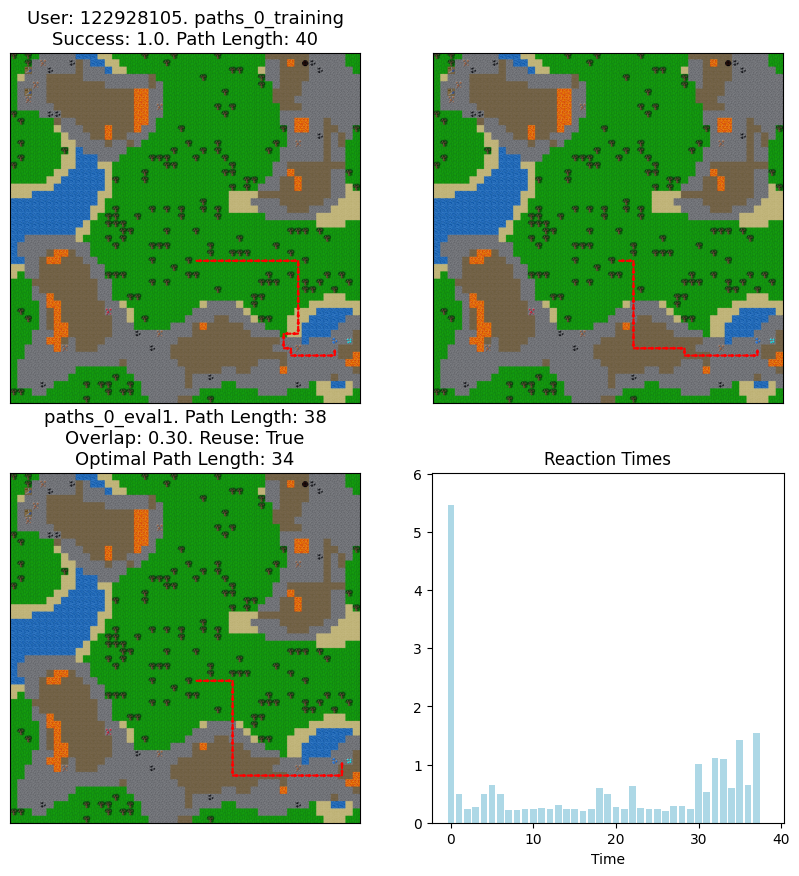

No test episodes for maze: paths_1_eval1
No test episodes for maze: paths_2_eval1


,index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,suboptimal_path,efficient_1.25,efficient_1.5,efficient_1.75,efficient_2,path_length_deviance,success,path_length,termination,first_log_rt,avg_log_rt,total_log_rt,log_avg_post_rt,max_log_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,reuse,overlap,efficient_reuse_1.25,efficient_reuse_1.5,efficient_reuse_1.75,efficient_reuse_2
0,0,95,1,paths_3_eval1,reusing longer of two paths which matches training path,paths,16,1,True,10,0,[ 7 16],122928105,53,Female,craftax_v3-paths-r0-m0,0,0,0,3,27,False,True,True,True,True,2,1.0,29,1.0,8.881281,6.466161,187.518677,6.379907,8.881281,7.347944,7.284135,7.347944,7.347944,1,0.625,True,True,True,True


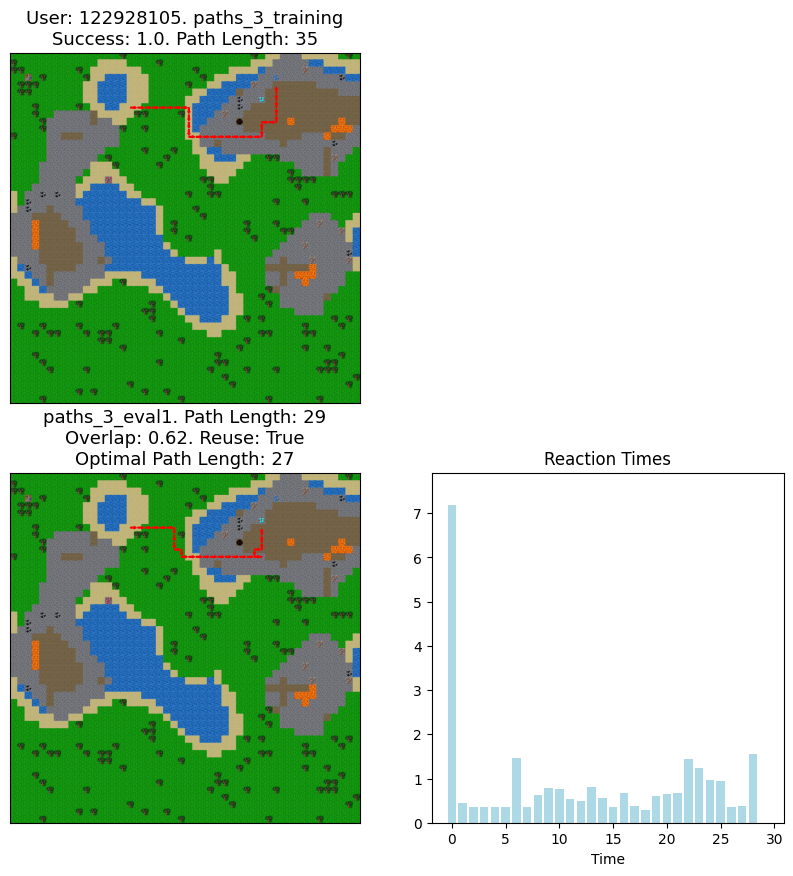






818906834


,index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,suboptimal_path,efficient_1.25,efficient_1.5,efficient_1.75,efficient_2,path_length_deviance,success,path_length,termination,first_log_rt,avg_log_rt,total_log_rt,log_avg_post_rt,max_log_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,reuse,overlap,efficient_reuse_1.25,efficient_reuse_1.5,efficient_reuse_1.75,efficient_reuse_2
0,0,3,1,paths_0_eval1,reusing longer of two paths which matches training path,paths,51,1,True,10,0,[28 25],818906834,53,Female,craftax_v3-paths-r0-m0,0,0,0,3,34,False,True,True,True,True,3,1.0,37,1.0,6.070738,5.342988,197.690536,5.322773,6.09357,6.09357,6.09357,5.620401,5.620401,1,0.285714,True,True,True,True


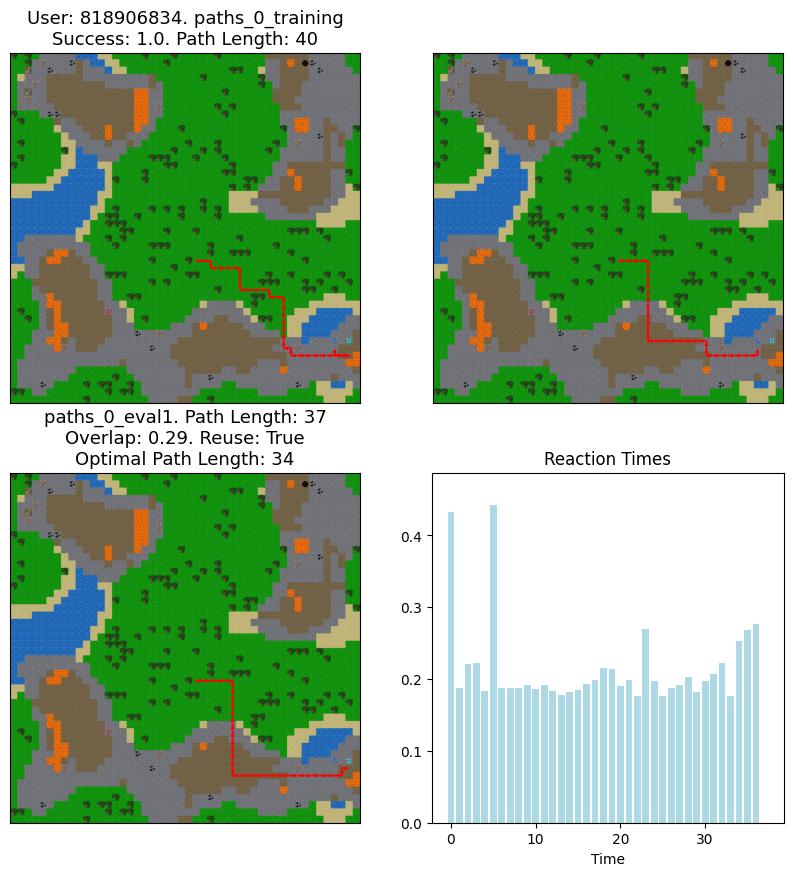

No test episodes for maze: paths_1_eval1


,index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,suboptimal_path,efficient_1.25,efficient_1.5,efficient_1.75,efficient_2,path_length_deviance,success,path_length,termination,first_log_rt,avg_log_rt,total_log_rt,log_avg_post_rt,max_log_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,reuse,overlap,efficient_reuse_1.25,efficient_reuse_1.5,efficient_reuse_1.75,efficient_reuse_2
0,0,20,1,paths_2_eval1,reusing longer of two paths which matches training path,paths,33,1,True,22,0,[18 30],818906834,53,Female,craftax_v3-paths-r0-m0,0,0,0,3,32,False,True,True,True,True,7,1.0,39,1.0,6.54103,5.391817,210.280869,5.361575,6.54103,6.113682,5.480639,6.113682,6.113682,1,0.364706,True,True,True,True


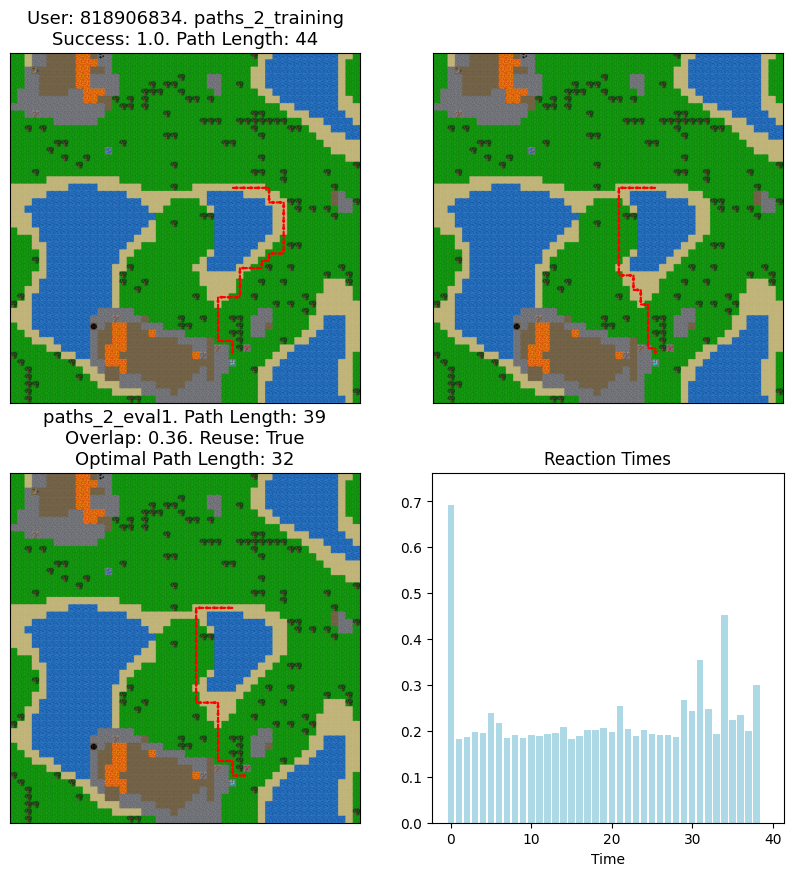

,index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,suboptimal_path,efficient_1.25,efficient_1.5,efficient_1.75,efficient_2,path_length_deviance,success,path_length,termination,first_log_rt,avg_log_rt,total_log_rt,log_avg_post_rt,max_log_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,reuse,overlap,efficient_reuse_1.25,efficient_reuse_1.5,efficient_reuse_1.75,efficient_reuse_2
0,0,95,1,paths_3_eval1,reusing longer of two paths which matches training path,paths,68,1,True,10,0,[ 7 16],818906834,53,Female,craftax_v3-paths-r0-m0,0,0,0,3,27,False,True,True,True,True,4,1.0,31,1.0,6.403574,5.39936,167.380157,5.365886,6.403574,5.869297,5.537334,5.869297,5.869297,1,0.321429,True,True,True,True


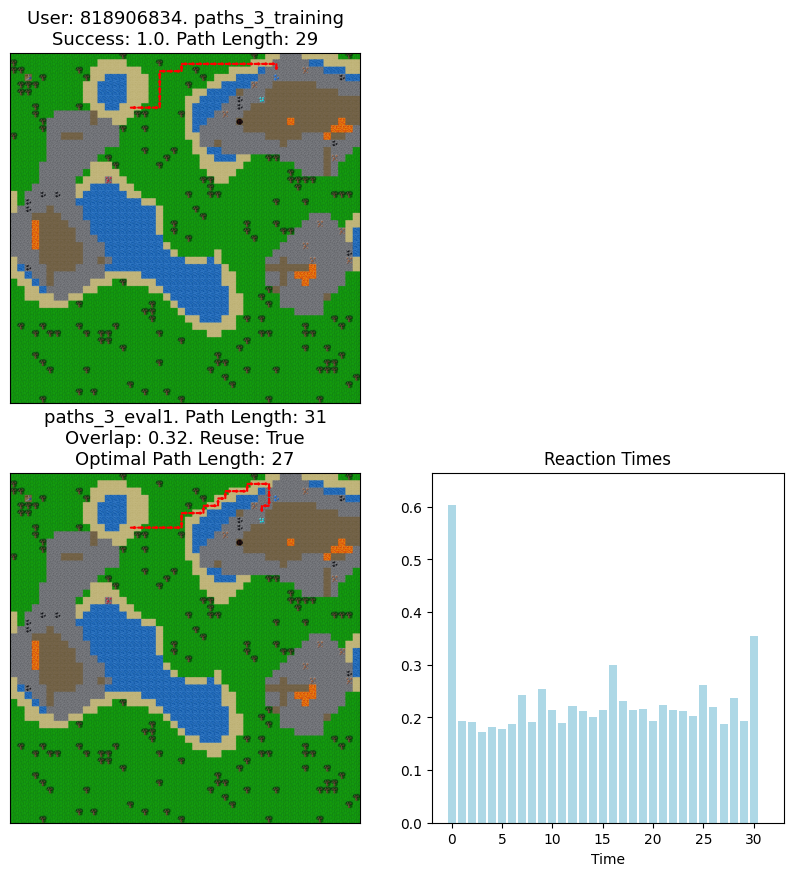






2349435691
No test episodes for maze: paths_0_eval1
No test episodes for maze: paths_1_eval1
No test episodes for maze: paths_2_eval1
No test episodes for maze: paths_3_eval1





2540827707
No test episodes for maze: paths_0_eval1


,index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,suboptimal_path,efficient_1.25,efficient_1.5,efficient_1.75,efficient_2,path_length_deviance,success,path_length,termination,first_log_rt,avg_log_rt,total_log_rt,log_avg_post_rt,max_log_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,reuse,overlap,efficient_reuse_1.25,efficient_reuse_1.5,efficient_reuse_1.75,efficient_reuse_2
0,0,15,1,paths_1_eval1,reusing longer of two paths which matches training path,paths,50,1,True,21,0,[24 24],2540827707,49,Male,craftax_v3-paths-r0-m0,0,0,0,3,38,False,True,True,True,True,6,1.0,44,1.0,6.952729,5.932005,261.008209,5.908267,7.565275,7.565275,6.785588,7.565275,7.565275,1,0.27027,True,True,True,True


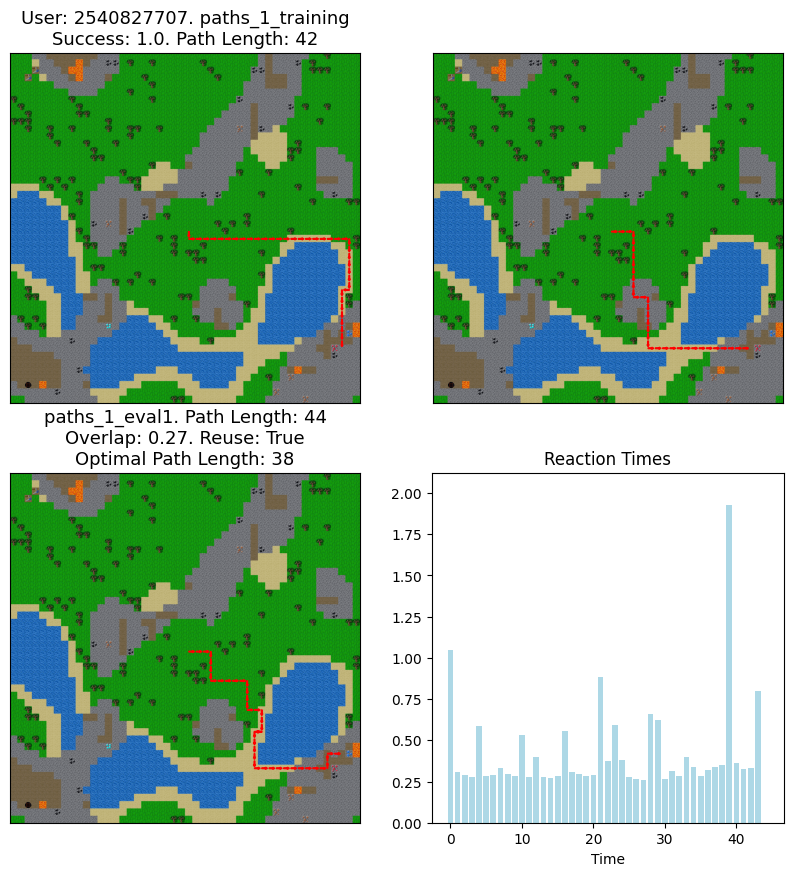

No test episodes for maze: paths_2_eval1


,index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,suboptimal_path,efficient_1.25,efficient_1.5,efficient_1.75,efficient_2,path_length_deviance,success,path_length,termination,first_log_rt,avg_log_rt,total_log_rt,log_avg_post_rt,max_log_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,reuse,overlap,efficient_reuse_1.25,efficient_reuse_1.5,efficient_reuse_1.75,efficient_reuse_2
0,0,95,1,paths_3_eval1,reusing longer of two paths which matches training path,paths,33,1,True,10,0,[ 7 16],2540827707,49,Male,craftax_v3-paths-r0-m0,0,0,0,3,27,False,True,True,True,True,1,1.0,28,1.0,6.553934,5.632068,157.697906,5.597925,6.553934,6.364751,6.364751,6.329721,6.329721,1,0.42623,True,True,True,True


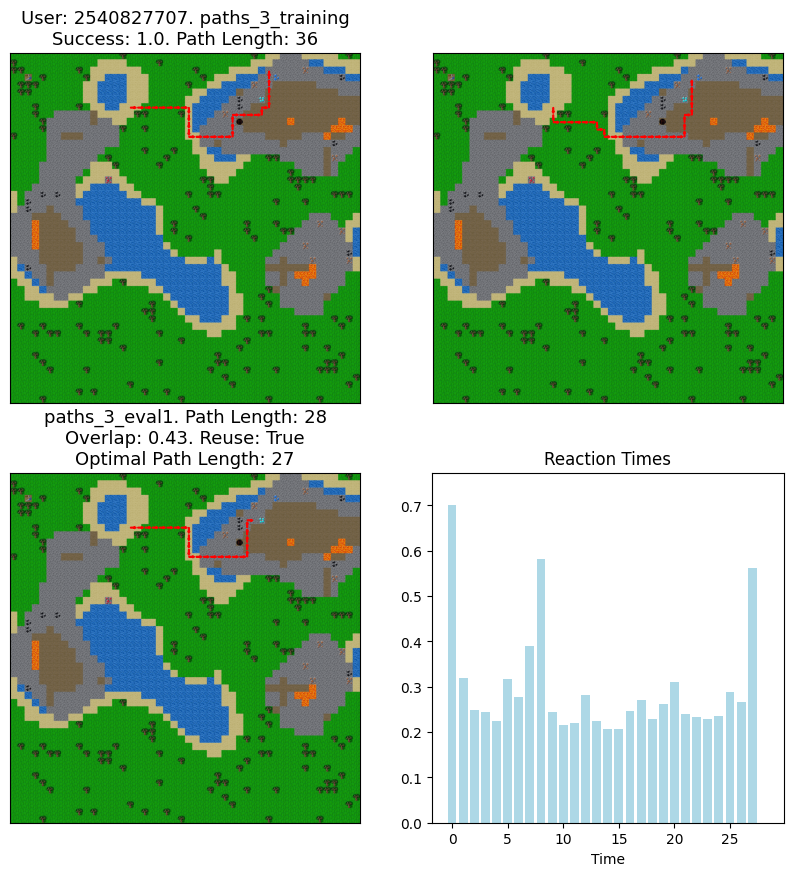

In [38]:
from IPython.display import HTML, display, Markdown

# Then you can display Markdown like this:
# suboptimal_df = sub_df.filter(suboptimal_path=True)
for user_id in users[:5]:
  # get df where user
  print("\n" * 4)
  print("=" * 100)
  print(user_id)
  print("=" * 100)
  craftax_analysis.visualize_user_path_reuse(
    sub_df, user_id, **{"efficient_reuse_1.25": True}
  )
  plt.show()






10434196
No test episodes for maze: paths_0_eval1
No test episodes for maze: paths_1_eval1
No test episodes for maze: paths_2_eval1
No test episodes for maze: paths_3_eval1





122928105
No test episodes for maze: paths_0_eval1
No test episodes for maze: paths_1_eval1
No test episodes for maze: paths_2_eval1
No test episodes for maze: paths_3_eval1





818906834
No test episodes for maze: paths_0_eval1
No test episodes for maze: paths_1_eval1
No test episodes for maze: paths_2_eval1
No test episodes for maze: paths_3_eval1





2349435691
No test episodes for maze: paths_0_eval1
No test episodes for maze: paths_1_eval1
No test episodes for maze: paths_2_eval1
No test episodes for maze: paths_3_eval1





2540827707
No test episodes for maze: paths_0_eval1
No test episodes for maze: paths_1_eval1


,index,world_seed,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,start_pos,user_id,age,sex,exp_name,tell_reuse,eval_map,timer,version,optimal_length,suboptimal_path,success,path_length,termination,first_log_rt,avg_log_rt,total_log_rt,log_avg_post_rt,max_log_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,optimal_length_deviance,reuse,overlap,efficient_reuse
0,0,20,1,paths_2_eval1,reusing longer of two paths which matches training path,paths,67,1,True,22,0,[18 30],2540827707,49,Male,craftax_v3-paths-r0-m0,0,0,0,3,33,True,1.0,81,1.0,6.814543,5.980825,484.446838,5.970404,7.738488,7.738488,7.284135,6.784457,7.738488,48,1,0.222222,False


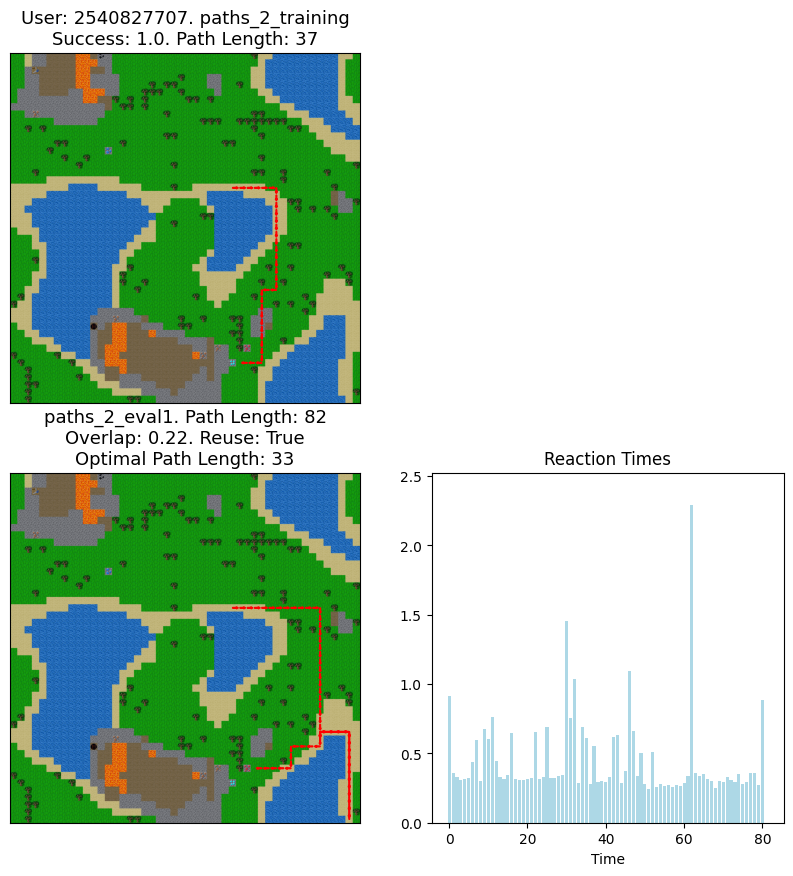

No test episodes for maze: paths_3_eval1


In [32]:
from IPython.display import HTML, display, Markdown

# Then you can display Markdown like this:
# suboptimal_df = sub_df.filter(suboptimal_path=True)
for user_id in users[:5]:
  # get df where user
  print("\n" * 4)
  print("=" * 100)
  print(user_id)
  print("=" * 100)
  craftax_analysis.visualize_user_path_reuse(
    sub_df, user_id, suboptimal_path=True, reuse=1
  )
  plt.show()